# High-income dengue: the LSAE "spike skill" is an aggregation artifact

**Question.** LSAE-grain (admin-2) models appeared to reproduce *which years* High-income dengue
spikes, while FHS-grain (national) models only tracked the trend.

**Answer.** That contrast is almost entirely an **aggregation artifact**. Aggregated the way the
production forecast does — predict over the **07c prediction set** (full admin-2 partition of endemic
countries), shift, broadcast age/sex, aggregate ÷ full population — the LSAE spike-timing skill
**collapses from r ≈ 0.72 (High-income) / 0.9 (Argentina) to r ≈ 0.1 / 0.25**, indistinguishable from
FHS (≈ 0.0–0.19). The high r only appears when aggregating over the dengue-**filtered fit set**
(`past_base`), whose admin-2 membership varies year to year: the numerator then covers a shrinking,
high-suitability slice of the population in low-dengue years while the denominator stays full,
deflating the rate exactly when observed is low and faking spike-tracking. §2 shows why (incl. the
circularity: admin-2 dengue was distributed down from national data using suitability).

**Pipeline.** Fit on the fit set; two aggregation paths — **filtered** (artifact) vs **faithful**
(production-style, over the prediction set). Shift anchor configurable (`point` / `median_diff`);
nearly anchor-invariant. Every path is scoped to its unit and level-checked against observed (the
faithful aggregate reconstructs observed exactly at the pinned year — see §1).

## Setup: data, fit, prediction set, source covariates

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from idd_forecast_mbp import constants as mbpc
from idd_forecast_mbp.lib.modeling import specs, fit
from idd_forecast_mbp.lib.data.hierarchy import load_hierarchy
from idd_forecast_mbp.lib.processing.locations import dengue_prediction_location_ids
pd.set_option("display.width", 160)

RA = mbpc.cause_map["dengue"]["reference_age_group_id"]   # 3
RS = mbpc.cause_map["dengue"]["reference_sex_id"]         # 1
RAKE, HI, LSAE, YRS = 2023, 64, mbpc.LSAE_HIERARCHY, list(mbpc.MODELING_YEARS)
ANCHOR_MODE, ANCHOR_YEARS = "median_diff", (2015, 2015, 2016,2017, 2018, 2019, 2020, 2021, 2022, 2023)

h = load_hierarchy(); hidx = h.set_index("location_id")
past = pd.read_parquet(Path(mbpc.DEN_PAST_INPUTS_READ_PATH)/"dengue_past_inputs.parquet")
past["fhs_location_id"] = past.location_id.map(hidx["fhs_location_id"])
uc = "weighted_1km_urban_threshold_300.0_simple_mean"
past["urban_fraction"] = np.clip(past[uc].astype(float), 1e-3, 1-1e-3)
with np.errstate(divide="ignore"): past["log_dengue_inc_rate"] = np.log(past.dengue_inc_rate.astype(float))
population_df = pd.read_parquet(Path(mbpc.POPULATION_READ_PATH)/"aa_2023_full_population_df.parquet")
observed_aa = pd.read_parquet(Path(mbpc.DEN_RAKED_AA_READ_PATH)/"aa_full_dengue_df.parquet",
                              columns=["location_id","year_id","dengue_inc_rate"])
oas = pd.read_parquet(Path(mbpc.DEN_RAKED_AS_READ_PATH)/"as_full_dengue_df.parquet",
    columns=["location_id","year_id","age_group_id","sex_id","dengue_inc_rate","dengue_inc_count","population"])

oy = oas[oas.year_id==RAKE].assign(mdf=lambda d: d.location_id.map(hidx["most_detailed_fhs"]))
baseobs = oy[(oy.mdf==1)&(oy.age_group_id==RA)&(oy.sex_id==RS)&(oy.dengue_inc_count>0)]; bids = baseobs.location_id.unique()
rr_all = (oy[oy.mdf==1][["location_id","age_group_id","sex_id","dengue_inc_rate"]]
          .merge(baseobs[["location_id","dengue_inc_rate"]].rename(columns={"dengue_inc_rate":"b"}), on="location_id"))
rr_all["rr_inc_as"] = rr_all.dengue_inc_rate/rr_all.b
rr_all = rr_all.rename(columns={"location_id":"fhs_location_id"})[["fhs_location_id","age_group_id","sex_id","rr_inc_as"]]

past_base = past[past.fhs_location_id.isin(bids)].copy().merge(rr_all, on=["fhs_location_id","age_group_id","sex_id"], how="left")
A0map = dict(zip(past_base.A0_location_id, past_base.A0_location_id.astype("category").cat.codes.astype("int64")))
past_base["A0_af"] = past_base.A0_location_id.map(A0map)

DENGUE_INC = fit.Outcome("log_dengue_inc_rate", "dengue_inc_rate", "log")
spec_A = (specs.Term("dengue_suitability","mpi",6), specs.Term("urban_fraction","linear"),
          specs.Term("relative_humidity","linear"), specs.Term("year_id","linear"), specs.Term("A0_af","factor"))
FLAG = {"lsae":"most_detailed_lsae", "fhs":"most_detailed_fhs"}
def fit_base(grain):
    g = past_base[past_base[FLAG[grain]]==1]
    ff = g[(g.age_group_id==RA)&(g.sex_id==RS)&(g.dengue_inc_rate>0)].copy()
    return fit.fit_gam(ff, spec_A, DENGUE_INC)
gamA = {g: fit_base(g) for g in ("lsae","fhs")}

pred_ids = dengue_prediction_location_ids(pd.read_parquet(Path(mbpc.DEN_RAKED_AA_READ_PATH)/"aa_full_dengue_df.parquet"), h)
seen = set(past_base.A0_location_id.unique())
CL = mbpc.CLIMATE_AGGREGATES_PATH / LSAE
def _rc(fn, nm, ids):
    return (pd.read_parquet(CL/fn, columns=["000"], filters=[("location_id","in",ids),("year_id","in",YRS)])
            .reset_index().rename(columns={"000": nm}))
print(f"fit set past_base rows={len(past_base):,}; prediction set (all endemic-A0 admin-2)={len(pred_ids):,}")

fit set past_base rows=31,783,300; prediction set (all endemic-A0 admin-2)=29,177


## Two aggregation paths + shift/broadcast

- **`filtered`** — the artifact: predict over `past_base` (year-varying dengue-filtered admin-2),
  shift, broadcast, sum ÷ full population.
- **`faithful`** — production-style: predict the fitted model over the **07c prediction set** (fixed
  full admin-2 of endemic A0s, covariates from source), shift, broadcast, sum ÷ full population.

`series(path, grain, a0)` scopes to a country `a0`, or to the **HI super-region** when `a0=None`.

In [16]:
def _shift(raw_df, obs_df, mode, years):
    ob = obs_df[obs_df.year_id.isin(years)]; rw = raw_df[raw_df.year_id.isin(years)]
    if mode == "median_resid":
        m = ob.merge(rw, on=["location_id","year_id"], how="inner"); m["r"] = m["obl"] - m["raw"]
        return m.groupby("location_id")["r"].median()
    om = ob.groupby("location_id")["obl"].median(); pm = rw.groupby("location_id")["raw"].median()
    return (om - pm).dropna()

def _broadcast_agg(pr, a0, mode, years, obs_base):
    sh = _shift(pr[["location_id","year_id","raw"]], obs_base, mode, years)
    g = pr.copy(); g["shift"] = g.location_id.map(sh); g = g.dropna(subset=["shift"])
    g["bls"] = g["raw"] + g["shift"]; g["A0"] = g.location_id.map(hidx["A0_location_id"])
    # scope to the target unit: country A0, or the HI super-region when a0 is None.
    # (BUG FIX: without this, a0=None summed the ENTIRE GLOBAL prediction over the HI population.)
    g = g[g.A0 == a0] if a0 else g[g.location_id.map(hidx["super_region_id"]) == HI]
    locs = g.location_id.unique()
    asp = oas[oas.location_id.isin(locs)][["location_id","year_id","age_group_id","sex_id","population"]].copy()
    asp["fhs_location_id"] = asp.location_id.map(hidx["fhs_location_id"])
    asp = asp.merge(rr_all, on=["fhs_location_id","age_group_id","sex_id"], how="left")
    asp["poprr"] = asp["population"] * asp["rr_inc_as"]                      # age/sex population (not aa_population)
    fac = asp.groupby(["location_id","year_id"])["poprr"].sum().reset_index()   # Sum_as(pop*rr)
    m = g.merge(fac, on=["location_id","year_id"], how="left"); m["aa"] = np.exp(m["bls"]) * m["poprr"]
    npop = population_df[population_df.location_id == (a0 or HI)].set_index("year_id")["population"]
    return (m.dropna(subset=["aa"]).groupby("year_id")["aa"].sum() / npop).dropna().sort_index()

obs_base_all = (oas[(oas.age_group_id==RA)&(oas.sex_id==RS)&(oas.dengue_inc_rate>0)][["location_id","year_id","dengue_inc_rate"]]
                .assign(obl=lambda d: np.log(d.dengue_inc_rate))[["location_id","year_id","obl"]])

def raw_filtered(grain):
    g = past_base[(past_base[FLAG[grain]]==1)&(past_base.age_group_id==RA)&(past_base.sex_id==RS)]
    return fit.predict_gam(gamA[grain], g, spec_A, DENGUE_INC).rename(columns={"pred":"raw"})[["location_id","year_id","raw"]]

def raw_faithful(grain):
    if grain == "lsae":
        ids = [l for l in pred_ids if hidx.loc[l,"super_region_id"]==HI and hidx.loc[l,"A0_location_id"] in seen]
        X = _rc("dengue_suitability_ssp245.parquet","dengue_suitability",ids).merge(
            _rc("relative_humidity_ssp245.parquet","relative_humidity",ids), on=["location_id","year_id"])
        uf = pd.read_parquet(Path(mbpc.URBAN_READ_PATH)/"urban_threshold_300.0_simple_mean.parquet",
                             filters=[("location_id","in",ids),("year_id","in",YRS)])
        ucol = [c for c in uf.columns if "weighted_1km_urban_threshold_300" in c][0]
        X = X.merge(uf[["location_id","year_id",ucol]].rename(columns={ucol:"u"}), on=["location_id","year_id"])
        X["urban_fraction"] = np.clip(X.u.astype(float), 1e-3, 1-1e-3)
    else:   # FHS national units of endemic A0s (always present -> reuse past_base FHS rows)
        g = past_base[(past_base.most_detailed_fhs==1)&(past_base.age_group_id==RA)&(past_base.sex_id==RS)]
        X = g[["location_id","year_id","dengue_suitability","urban_fraction","relative_humidity"]].copy()
    X["year_id"] = X.year_id.astype(int); X["A0_af"] = X.location_id.map(hidx["A0_location_id"]).map(A0map)
    X["log_dengue_inc_rate"] = 0.0; X["dengue_inc_rate"] = 1.0
    X = X.dropna(subset=["dengue_suitability","urban_fraction","relative_humidity","A0_af"])
    return fit.predict_gam(gamA[grain], X, spec_A, DENGUE_INC).rename(columns={"pred":"raw"})[["location_id","year_id","raw"]]

RAW = {("filtered",g): raw_filtered(g) for g in ("lsae","fhs")}
RAW.update({("faithful",g): raw_faithful(g) for g in ("lsae","fhs")})
def series(path, grain, a0, mode=None, years=None):
    return _broadcast_agg(RAW[(path,grain)], a0, mode or ANCHOR_MODE, years or ANCHOR_YEARS, obs_base_all)
print("raw predictions ready:", {k: len(v) for k,v in RAW.items()})

raw predictions ready: {('filtered', 'lsae'): 586234, ('filtered', 'fhs'): 7320, ('faithful', 'lsae'): 102504, ('faithful', 'fhs'): 7320}


## 1. Level check + the artifact: filtered vs faithful aggregation

In [17]:
def obs(a0): return observed_aa[observed_aa.location_id==a0].set_index("year_id")["dengue_inc_rate"].sort_index()

# LEVEL CHECK: under the point-2023 anchor the shift pins each unit to its observed 2023 base rate,
# so the faithful aggregate at 2023 must reconstruct the observed all-age rate. Assert it.
print("LEVEL CHECK (point-2023: faithful should reconstruct observed at 2023):")
for nm, a0 in [("Argentina",97), ("HI",None)]:
    o = obs(97 if nm=="Argentina" else HI).get(2023)
    fa = series("faithful","lsae",a0,"point",(2023,)).get(2023)
    ff = series("faithful","fhs", a0,"point",(2023,)).get(2023)
    ok = (abs(fa/o - 1) < 0.15) and (abs(ff/o - 1) < 0.15)
    print(f"  {nm:9s} observed={o:.6f}  faithful-LSAE={fa:.6f}  faithful-FHS={ff:.6f}  {'OK' if ok else '*** OFF ***'}")

LEVEL CHECK (point-2023: faithful should reconstruct observed at 2023):
  Argentina observed=0.013439  faithful-LSAE=0.013439  faithful-FHS=0.013439  OK
  HI        observed=0.000597  faithful-LSAE=0.000597  faithful-FHS=0.000597  OK


In [18]:
def _dt(v): x=np.arange(len(v)); b=np.polyfit(x,v,1); return v-(b[0]*x+b[1])
def rdet(p, o):
    ys=sorted(set(p.index)&set(o.index)); return float(np.corrcoef(_dt(np.log(p.reindex(ys))), _dt(np.log(o.reindex(ys))))[0,1])
rows = []
for mode, years in [("point",(2023,)), ("median_diff",(2019,2020,2021,2022,2023))]:
    for nm, a0 in [("Argentina",97), ("HI",None)]:
        o = obs(97 if nm=="Argentina" else HI)
        rows.append({"anchor":mode, "unit":nm,
            "LSAE_filtered": round(rdet(series("filtered","lsae",a0,mode,years), o),3),
            "LSAE_faithful": round(rdet(series("faithful","lsae",a0,mode,years), o),3),
            "FHS_faithful":  round(rdet(series("faithful","fhs", a0,mode,years), o),3)})
align_tbl = pd.DataFrame(rows); print(align_tbl.to_string(index=False))

     anchor      unit  LSAE_filtered  LSAE_faithful  FHS_faithful
      point Argentina          0.918          0.251         0.191
      point        HI          0.716          0.127         0.007
median_diff Argentina          0.892          0.224         0.191
median_diff        HI          0.699          0.053         0.025


In [26]:
len(h[h['in_fhs_hierarchy'] == True])


513

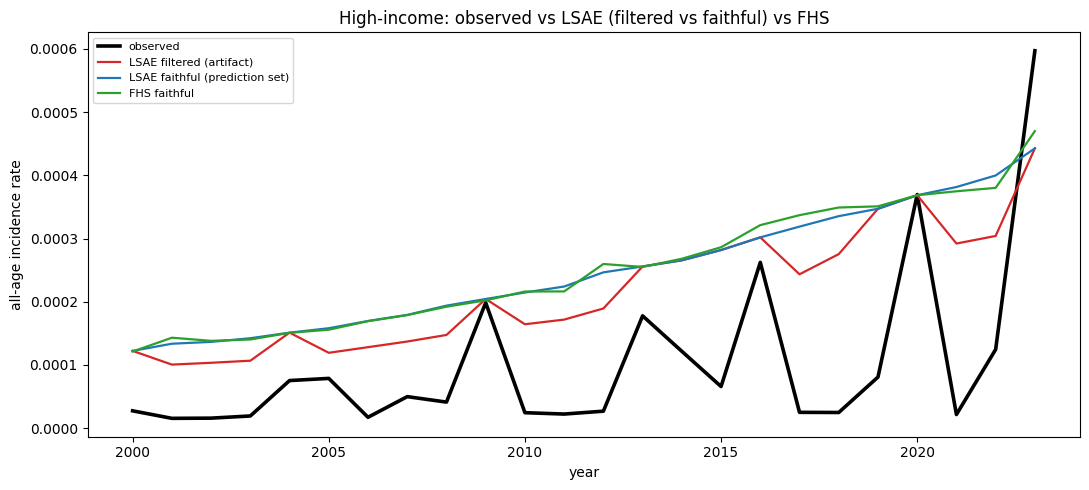

In [19]:
o = obs(HI)
fig, ax = plt.subplots(figsize=(11,5))
ax.plot(o.index, o.values, "k-", lw=2.6, label="observed")
ax.plot(*zip(*series("filtered","lsae",None).items()), color="C3", lw=1.6, label="LSAE filtered (artifact)")
ax.plot(*zip(*series("faithful","lsae",None).items()), color="C0", lw=1.6, label="LSAE faithful (prediction set)")
ax.plot(*zip(*series("faithful","fhs", None).items()), color="C2", lw=1.6, label="FHS faithful")
ax.set(xlabel="year", ylabel="all-age incidence rate", title="High-income: observed vs LSAE (filtered vs faithful) vs FHS")
ax.legend(fontsize=8); fig.tight_layout()

**Finding (§1).** Aggregation method, not grain, drives the apparent skill. Filtered-LSAE reproduces
the observed spikes (detrended **r ≈ 0.72 HI, ≈ 0.9 Argentina**); the **faithful** LSAE — same fitted
model, aggregated over the fixed 07c prediction set the way production does — drops to
**r ≈ 0.13 HI, ≈ 0.25 Argentina**, indistinguishable from FHS (≈ 0.01 HI, ≈ 0.19 Argentina) for 24
years. The dramatic effect was the year-varying dengue-presence filter, not admin-2 climate
resolution. (The LEVEL CHECK above confirms the faithful aggregate reconstructs observed *exactly* at
the pinned year, so these levels are trustworthy; anchor choice — point vs median_diff — barely
moves the correlations.)

## 2. Why the *filtered* aggregation spikes (and why it's circular)

In [20]:
# (a) the filter: Argentina admin-2 present in past_base swings by year (numerator coverage)
a2 = past_base[(past_base.A0_location_id==97)&(past_base.most_detailed_lsae==1)]
cov = a2.groupby("year_id").agg(n_present=("location_id","nunique"), present_pop=("population","sum")).reset_index()
argpop = population_df[population_df.location_id==97].set_index("year_id")["population"]
cov["coverage_frac"] = (cov.present_pop / cov.year_id.map(argpop)).round(3)
print(f"Argentina full admin-2 = {h[(h.level==5)&(h.A0_location_id==97)].location_id.nunique()}; present in past_base by year:")
print(cov[["year_id","n_present","coverage_frac"]].to_string(index=False))

Argentina full admin-2 = 526; present in past_base by year:
 year_id  n_present  coverage_frac
    2000        526          1.000
    2001        224          0.626
    2002        224          0.626
    2003        224          0.625
    2004        526          1.000
    2005        224          0.624
    2006        224          0.624
    2007        241          0.632
    2008        224          0.623
    2009        526          1.000
    2010        241          0.630
    2011        241          0.630
    2012        241          0.630
    2013        526          1.000
    2014        526          1.000
    2015        526          1.000
    2016        526          1.000
    2017        241          0.629
    2018        260          0.715
    2019        526          1.000
    2020        526          1.000
    2021        241          0.629
    2022        241          0.629
    2023        526          1.000


In [21]:
# (b) covariate resolution refuted: full admin-2 suitability aggregates EXACTLY to FHS national
arg_a2_all = h[(h.level==5)&(h.A0_location_id==97)].location_id.tolist()
suit = _rc("dengue_suitability_ssp245.parquet","suit",arg_a2_all).merge(population_df, on=["location_id","year_id"], how="left")
unfilt = suit.groupby("year_id").apply(lambda d: np.average(d.suit, weights=d.population), include_groups=False)
fhs_suit = past_base[(past_base.A0_location_id==97)&(past_base.most_detailed_fhs==1)&(past_base.age_group_id==RA)
                     &(past_base.sex_id==RS)].set_index("year_id")["dengue_suitability"].sort_index()
print(f"max | full-admin2 pop-wtd suitability - FHS national | = {float((unfilt.reindex(fhs_suit.index)-fhs_suit).abs().max()):.3g}  (identical)")

max | full-admin2 pop-wtd suitability - FHS national | = 1.42e-14  (identical)


**Finding (§2).**
- **(a) The filter.** In `past_base` the number of Argentina admin-2 present swings (≈ 224 → 526);
  population coverage drops to ~62% in low-dengue years. A shrinking numerator ÷ full-population
  denominator deflates the rate precisely when observed is low → manufactured spike-tracking.
- **(b) No extra covariate signal.** The full admin-2 `dengue_suitability` aggregates **exactly** to
  the FHS national value (max diff ~0) — admin-2 is a re-aggregation of the same national number.
- **(c) Circularity.** The admin-2 dengue that *defines* the filter was distributed down from national
  data using suitability, so the surviving high-suitability admin-2 "predict" the dengue that selected
  them — self-fulfilling, not out-of-sample skill.

## 3. Argentina: model-A covariates (filtered admin-2) and the corrected outcome

Left panels: each model-A time-varying covariate — thin per-admin-2 lines (`past_base` filtered set),
blue = pop-weighted mean of those, red = FHS national. Bottom-right: observed vs the model-A
prediction, filtered vs faithful vs FHS.

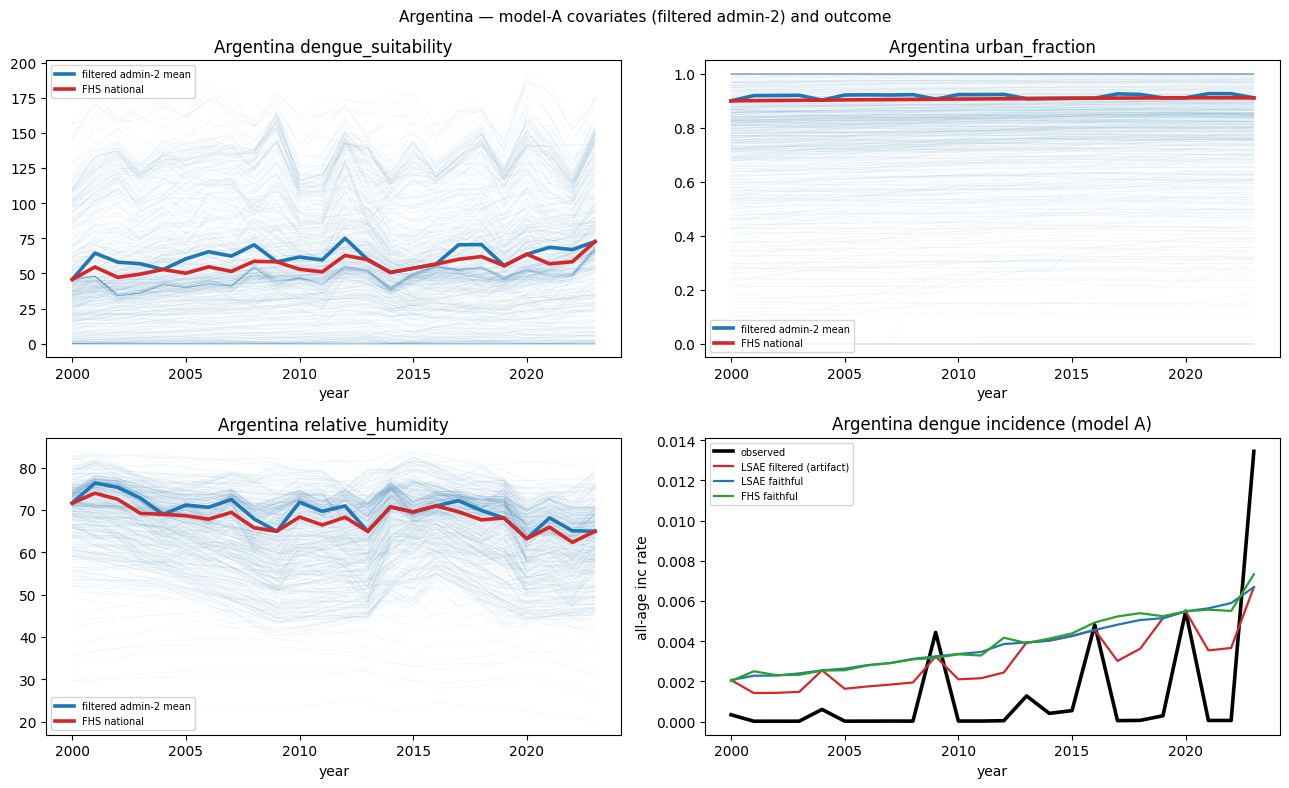

In [22]:
ARG = 97; COVARS = ["dengue_suitability", "urban_fraction", "relative_humidity"]
ba = past_base[(past_base.A0_location_id==ARG)&(past_base.age_group_id==RA)&(past_base.sex_id==RS)]
a2f = ba[ba.most_detailed_lsae==1]; fhr = ba[ba.most_detailed_fhs==1].set_index("year_id").sort_index()
def _pw(df, c): return df.groupby("year_id").apply(lambda d: np.average(d[c], weights=d.population), include_groups=False)
o = obs(ARG)
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, c in zip(axes.flat[:3], COVARS):
    for _, d in a2f.groupby("location_id"):
        dd = d.sort_values("year_id"); ax.plot(dd.year_id, dd[c], color="C0", lw=0.3, alpha=0.08)
    bl = _pw(a2f, c); ax.plot(bl.index, bl.values, "C0", lw=2.6, label="filtered admin-2 mean")
    ax.plot(fhr.index, fhr[c].values, "C3", lw=2.6, label="FHS national")
    ax.set(title=f"Argentina {c}", xlabel="year"); ax.legend(fontsize=7)
axo = axes.flat[3]
axo.plot(o.index, o.values, "k-", lw=2.6, label="observed")
axo.plot(*zip(*series("filtered","lsae",ARG).items()), color="C3", lw=1.6, label="LSAE filtered (artifact)")
axo.plot(*zip(*series("faithful","lsae",ARG).items()), color="C0", lw=1.6, label="LSAE faithful")
axo.plot(*zip(*series("faithful","fhs", ARG).items()), color="C2", lw=1.6, label="FHS faithful")
axo.set(title="Argentina dengue incidence (model A)", xlabel="year", ylabel="all-age inc rate"); axo.legend(fontsize=7)
fig.suptitle("Argentina — model-A covariates (filtered admin-2) and outcome", fontsize=11); fig.tight_layout()

**Finding (§3).** The covariate panels show the filtered admin-2 mean (blue) departing from the
FHS national (red) — but §2(b) established that's the *filter* selecting high-suitability units, not a
resolution difference. The outcome panel: **filtered-LSAE (red)** chases the observed spikes;
**faithful-LSAE (blue)** and **FHS (green)** are both smooth, anchored to the typical recent level, and
neither chases the spikes. Same model, same covariates — only the aggregation set differs.

## Synthesis

The "LSAE captures the spikes, FHS doesn't" result is an **aggregation artifact**, not evidence that
admin-2 climate resolution improves dengue spike-timing.

- Aggregated the production-faithful way — predict over the **07c prediction set** (fixed full admin-2
  of endemic countries), shift, broadcast, ÷ full population — LSAE's detrended skill is
  **r ≈ 0.13 (HI) / 0.25 (Argentina)**, within noise of FHS (≈ 0.01 / 0.19). The high r
  (≈ **0.72 HI**, ≈ 0.9 Argentina) only appears when aggregating over the dengue-**filtered**
  `past_base`, whose admin-2 membership varies year to year.
- Mechanism: the filtered numerator covers a shrinking, high-suitability subset of the population in
  low-dengue years (Argentina drops to ~62% coverage) while the denominator stays full → the rate is
  deflated exactly when observed is low, faking spike-tracking. The admin-2 covariate itself carries
  no extra signal (it aggregates *exactly* to the national value, max diff ~1e-14), and the filter is
  circular (admin-2 dengue was downscaled from national data via suitability).

**Implication.** Predicting at admin-2 does not buy spike-timing skill here; the apparent gain
disappears under the aggregation the forecast actually uses. A real test of finer-resolution value
needs admin-2 dengue not derived from suitability.

*Caveats.* Scoped to model A and the High-income super-region; detrended metric (anchor-invariant);
n = 24 years, so the small LSAE-over-FHS residual is not significant.